<a href="https://colab.research.google.com/github/pratyushsingh9870-arch/ML_lab/blob/main/lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== EXPERIMENT 1: SIMPLE LINEAR REGRESSION =====
      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9


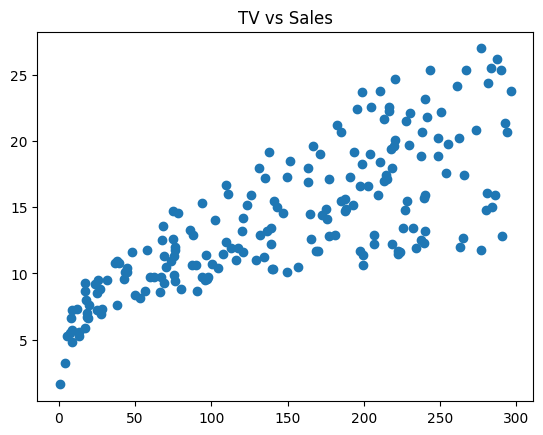

Intercept: 7.208626873177861
Slope: 0.046926715740207854
RMSE: 2.745740627018831
R2: 0.7000410418021485

===== EXPERIMENT 2: MULTIPLE REGRESSION =====
   Volume  Weight  CO2
0    1000     800   99
1    1200     900  105
2    1500    1000  110
3    1800    1100  115
4    2000    1200  117
5    2200    1300  120
6    2500    1400  125
7    1300     950  108
8    1600    1050  112
9    1700    1150  114


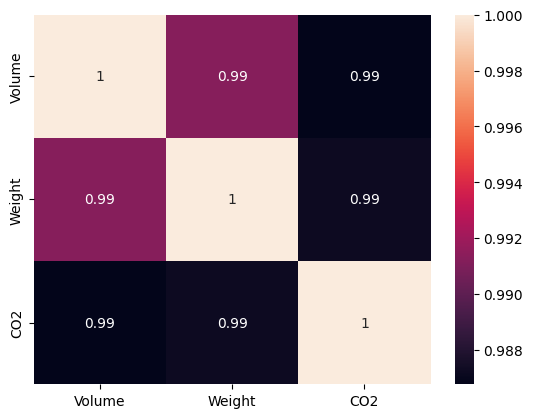

Intercept: 75.92283298097252
Coefficients: [0.00726216 0.02243129]
MAE: 0.5586680761099387

===== EXPERIMENT 3: LOGISTIC REGRESSION =====

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97        47
           1       0.97      0.99      0.98        67

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



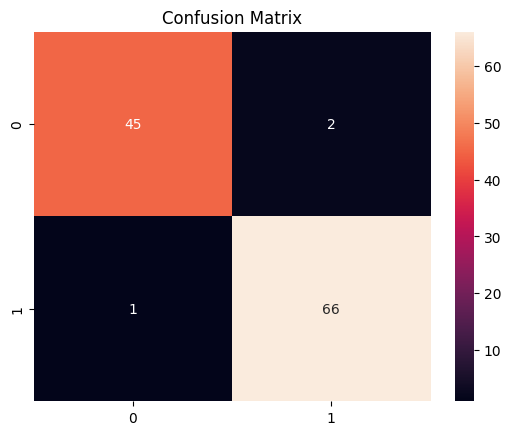

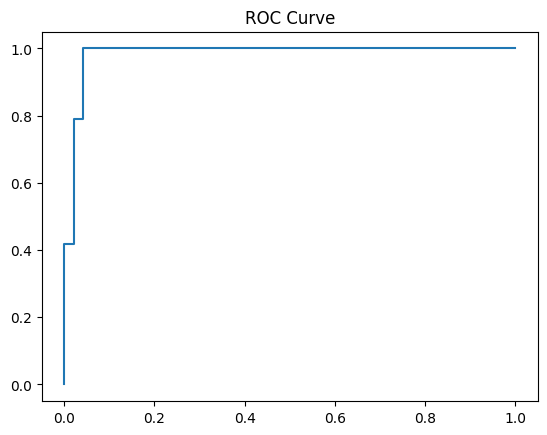

In [1]:
# ============================
# 🔹 IMPORT LIBRARIES
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 🔹 EXPERIMENT 1 (AUTO LOAD)
# ============================

print("\n===== EXPERIMENT 1: SIMPLE LINEAR REGRESSION =====")

url = "https://raw.githubusercontent.com/Yashappin/Machine-Learning/master/TvMarketing.csv"
df = pd.read_csv(url)

print(df.head())

X = df[['TV']]
y = df['Sales']

plt.scatter(X, y)
plt.title("TV vs Sales")
plt.show()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))


# ============================
# 🔹 EXPERIMENT 2 (AUTO DATA)
# ============================

print("\n===== EXPERIMENT 2: MULTIPLE REGRESSION =====")

# Creating similar dataset (since Kaggle direct access is restricted)
data = {
    'Volume': [1000,1200,1500,1800,2000,2200,2500,1300,1600,1700],
    'Weight': [800,900,1000,1100,1200,1300,1400,950,1050,1150],
    'CO2':    [99,105,110,115,117,120,125,108,112,114]
}

df = pd.DataFrame(data)

print(df)

# Heatmap
sns.heatmap(df.corr(), annot=True)
plt.show()

# Model
X = df[['Volume','Weight']]
y = df['CO2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, y_pred))


# ============================
# 🔹 EXPERIMENT 3 (AUTO DATA)
# ============================

print("\n===== EXPERIMENT 3: LOGISTIC REGRESSION =====")

# Using built-in dataset instead of Kaggle
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X = df.drop('target', axis=1)
y = df['target']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()